In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

Section 1: Data Loading

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

Section 2: Data Cleaning

In [ ]:
df=pd.read_csv("retail_store_sales.csv")
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [ ]:
#  اول 10 صفوف من الداتا اللي فيها مشاكل في الكميه اوالاجمالي

df[df['Quantity'].isna() | df['Total Spent'].isna()][['Price Per Unit', 'Quantity', 'Total Spent']].head(10)


,Price Per Unit,Quantity,Total Spent
7,33.5,NaN,NaN
15,24.5,NaN,NaN
19,35.0,NaN,NaN
25,39.5,NaN,NaN
34,23.0,NaN,NaN
83,15.5,NaN,NaN
112,20.0,NaN,NaN
114,39.5,NaN,NaN
118,27.5,NaN,NaN
138,35.0,NaN,NaN


In [ ]:
# random_state=42 يخلي العشوائية ثابتة  يعني كل مرة نفس النتائج

df[df['Total Spent'].isna()][['Price Per Unit', 'Quantity', 'Total Spent']].sample(10, random_state=42)

,Price Per Unit,Quantity,Total Spent
2402,24.5,NaN,NaN
9605,33.5,NaN,NaN
11930,41.0,NaN,NaN
1760,12.5,NaN,NaN
3832,21.5,NaN,NaN
5903,24.5,NaN,NaN
139,24.5,NaN,NaN
10071,20.0,NaN,NaN
1767,27.5,NaN,NaN
7511,14.0,NaN,NaN


مفيش ولا معلومات كافيه نحسب منها الاجمالي لان الكميه ناقصه بالكامل

القرار الصح نحذف الصفوف دي لان الكميه ناقصه فمستحيل نحسب التوتال بشكل صحيح لان لو حسبناه وهو مش صح هياثر علي الموديل

مش هنعوض لان القيم الناقصه للاتنين بيجو مع بعض في نفس الصفوف والكميه ده رقم اساسي والتوتال بيعتمد عليه فاي تعويض هيكون تخمين وده هيبوظ الموديل

In [ ]:
df = df.dropna(subset=['Quantity', 'Total Spent'])

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,609
Price Per Unit,609
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
df.shape

(11971, 11)

كدا انا عندي اسم المنتج وسعره هما اللي ناقصين لاكن الكميه والاجمالي موجودين فكدا مينفعش احذف هعوض لان كدا عندي نقص في وصف المنتج فممكن اعوضه

ومينفعش احذف لان الكميه والاجمالي موجودين وده مفيد للتوقع

In [ ]:
df['Item'] = df['Item'].fillna('Unknown')

In [ ]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(
    df['Total Spent'] / df['Quantity']
)

In [ ]:
df['Discount Applied'] = df['Discount Applied'].fillna('False')

In [ ]:
df = df.drop(columns=['Transaction ID', 'Customer ID'])

In [ ]:
df.isnull().sum()

,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0
Discount Applied,0


Section 3: Data Processing

In [ ]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [ ]:
df= df.sort_values('Transaction Date')

In [ ]:
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day
df['Weekday'] = df['Transaction Date'].dt.weekday


In [ ]:
daily_sales = df.groupby('Transaction Date')['Total Spent'].sum().reset_index()

In [ ]:
# تغير اسماء الاعمده لسهوله التعامل معاها
daily_sales.columns = ['Date', 'Sales']

In [ ]:
print(daily_sales.head(10))

        Date   Sales
0 2022-01-01  1642.5
1 2022-01-02  1135.5
2 2022-01-03   823.0
3 2022-01-04  1117.5
4 2022-01-05  2227.5
5 2022-01-06   763.5
6 2022-01-07  1372.5
7 2022-01-08  1496.5
8 2022-01-09  1866.0
9 2022-01-10  1340.5


In [ ]:
df['Discount Applied'] = df['Discount Applied'].astype(str)

In [ ]:
df['Quantity'] = df['Quantity'].astype(int)

In [ ]:
df.head()

,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Day,Weekday
10832,Electric household essentials,Item_21_EHE,35.0,10,350.0,Cash,Online,2022-01-01,True,2022,1,1,5
3327,Computers and electric accessories,Item_6_CEA,12.5,6,75.0,Digital Wallet,In-store,2022-01-01,True,2022,1,1,5
3076,Milk Products,Item_4_MILK,9.5,7,66.5,Credit Card,Online,2022-01-01,False,2022,1,1,5
5790,Beverages,Item_8_BEV,15.5,5,77.5,Credit Card,Online,2022-01-01,True,2022,1,1,5
9153,Food,Item_18_FOOD,30.5,10,305.0,Digital Wallet,In-store,2022-01-01,False,2022,1,1,5


In [ ]:
categorical_cols = ['Category', 'Item', 'Payment Method', 'Location']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

display(df.head())

,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Day,Weekday
10832,3,99,35.0,10,350.0,0,1,2022-01-01,True,2022,1,1,5
3327,2,170,12.5,6,75.0,2,0,2022-01-01,True,2022,1,1,5
3076,6,158,9.5,7,66.5,1,1,2022-01-01,False,2022,1,1,5
5790,0,184,15.5,5,77.5,1,1,2022-01-01,True,2022,1,1,5
9153,4,68,30.5,10,305.0,2,0,2022-01-01,False,2022,1,1,5


In [ ]:
df['Discount Applied']=le.fit_transform(df['Discount Applied'])

In [ ]:
df.head()

,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Day,Weekday
10832,3,99,35.0,10,350.0,0,1,2022-01-01,1,2022,1,1,5
3327,2,170,12.5,6,75.0,2,0,2022-01-01,1,2022,1,1,5
3076,6,158,9.5,7,66.5,1,1,2022-01-01,0,2022,1,1,5
5790,0,184,15.5,5,77.5,1,1,2022-01-01,1,2022,1,1,5
9153,4,68,30.5,10,305.0,2,0,2022-01-01,0,2022,1,1,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11971 entries, 10832 to 11069
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Category          11971 non-null  int64         
 1   Item              11971 non-null  int64         
 2   Price Per Unit    11971 non-null  float64       
 3   Quantity          11971 non-null  int64         
 4   Total Spent       11971 non-null  float64       
 5   Payment Method    11971 non-null  int64         
 6   Location          11971 non-null  int64         
 7   Transaction Date  11971 non-null  datetime64[ns]
 8   Discount Applied  11971 non-null  int64         
 9   Year              11971 non-null  int32         
 10  Month             11971 non-null  int32         
 11  Day               11971 non-null  int32         
 12  Weekday           11971 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(4), int64(6)
memory usage: 1.1 MB


The cleaned data has been saved to `retail_store_sales_cleaned.csv`.

In [ ]:
df.to_csv('retail_store_sales_cleaned.csv', index=False)

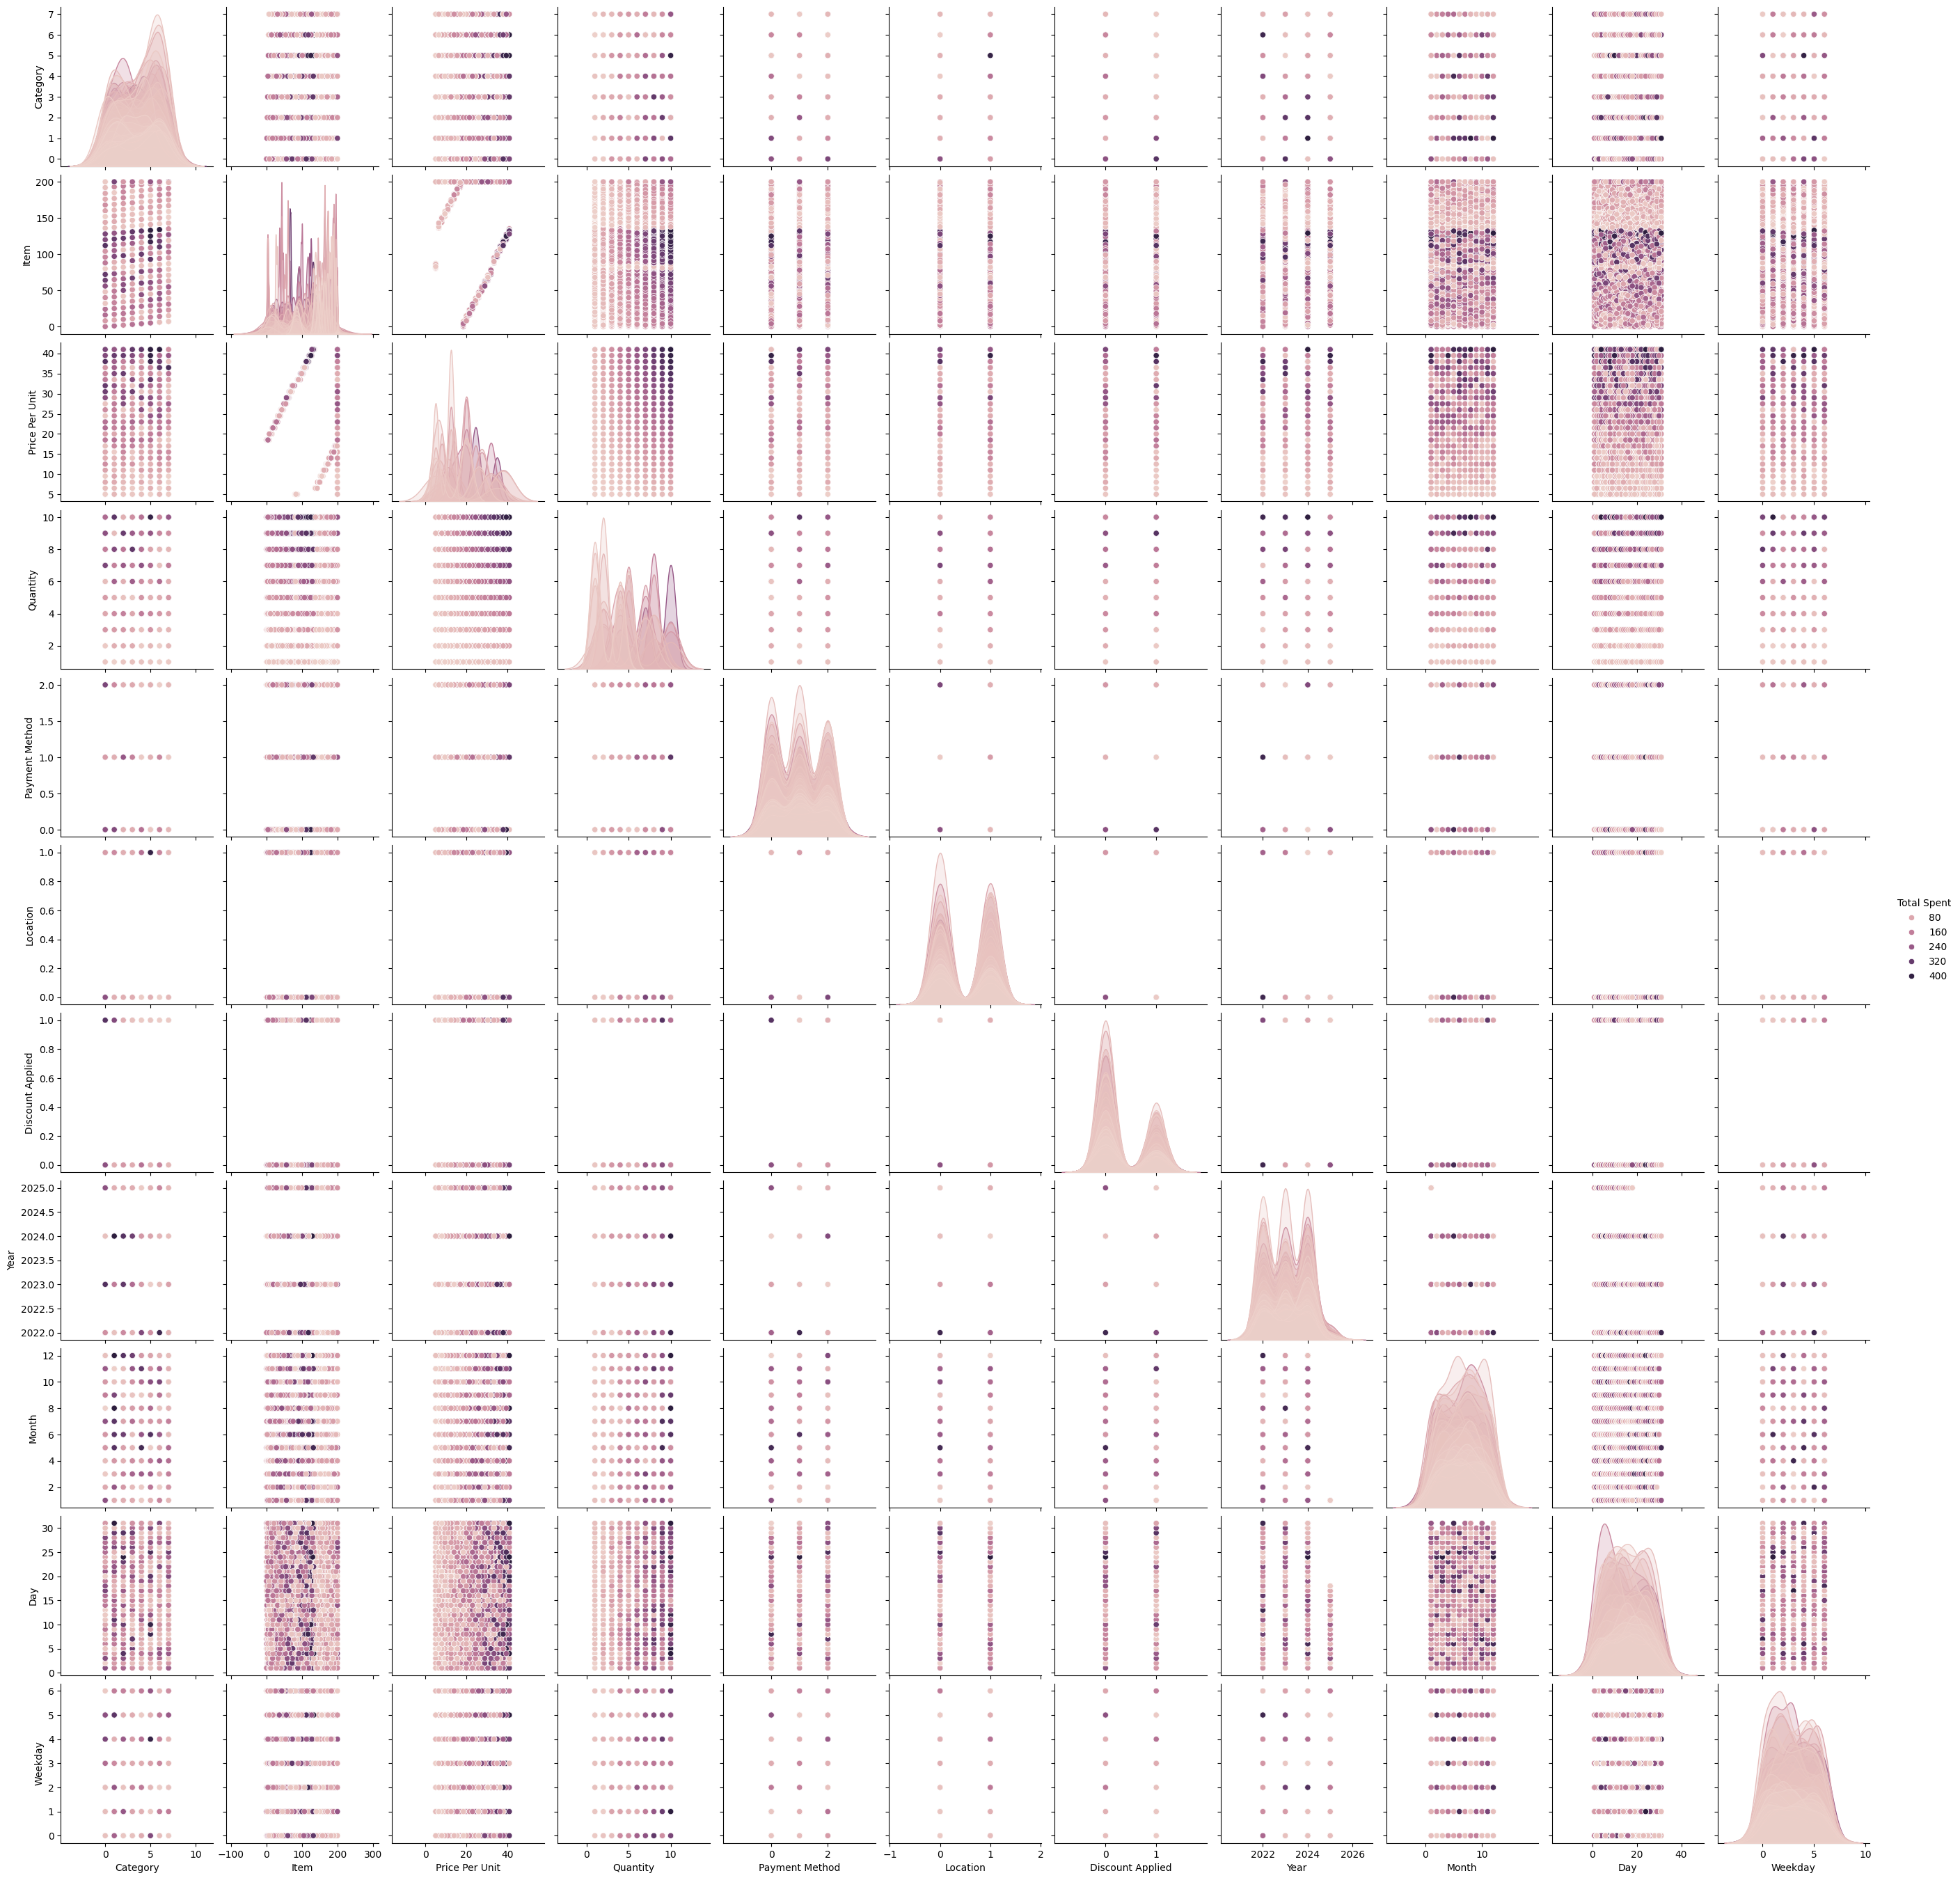

In [ ]:
sns.pairplot(df , hue="")
